# Lecture 15 — Line Blanketing: the True Model Atmosphere *(GPU Edition)*

*Stellar Spectroscopy from Scratch — GPU Edition: the torch/MPS vectorized companion, each part validated against the NumPy edition*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*This is the **GPU edition** of Lecture 15. The physics and the formulas are identical to the [NumPy edition](https://github.com/tingyuansen/stellar-spectroscopy-from-scratch); the line deposit and the line-blanketed convergence engine are rebuilt in clean, depth-batched **`torch`**. But this lecture has a second job. Lectures 15 and 16 are the **atmosphere-convergence** finale, and on the GPU — where the working precision is **fp32** (Apple MPS and CUDA have no float64) — the full convergence loop **diverges**. That divergence is not a bug to hide; it is a result to **localise**. So every cell here runs **twice** — once on the working device in fp32, once on the CPU in fp64 — and reports the per-cell maximum relative deviation. The comparison walks down the pipeline and shows **exactly which cell** single precision peels away from the fp64 reference. The clean torch port is a pedagogical reduction of the production `kgpu` engine; the notebook imports neither `kgpu` nor pykurucz.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Deposit a spectral line the way the production engine does — the **asymmetric sub-pixel wing-walk**, the **full three-branch Voigt** $H(a,v)$, and the **continuum-cutoff reach** — written as a clean depth-batched `torch` kernel.
- Fold the line blanket into the **Rosseland mean** opacity (the harmonic, $\partial B/\partial T$-weighted average of the total extinction) and integrate it to the **Rosseland optical depth** $\tau_{\rm Ross}$.
- Run **one iteration** of the line-blanketed convergence engine — the frequency sweep, the temperature correction, the column-mass update — and see the back-warming that builds the real Sun's atmosphere.
- **Run the fp32-vs-fp64 diagnostic cell by cell** and read off where the divergence enters: confirm (or refute) that the per-evaluation physics is fp32-safe to the float floor, and that the convergence-core **secant** $(\,p_2-p_1)/p_1$ is the catastrophic-cancellation point that needs fp64.

## Why this lecture diverges in fp32 — and why that is the lesson

Up to Lecture 14 every GPU port held fp32 parity with the NumPy edition to a few $\times 10^{-6}$: the equation of state, the continuum, the lines, the molecular bands, the radiative transfer. Those are all **per-evaluation** computations — given the atmosphere, evaluate an opacity or a flux. Single precision handles them comfortably, because each number is computed *once* from well-conditioned inputs.

The **atmosphere convergence** is different. It is an *iteration*: start from a guess, compute the radiation field, correct the temperature and the column mass, repeat ~20–30 times until the structure stops moving. Two things make this fragile in fp32. First, the correction is a **finite difference** — it compares the pressure structure at temperature $T$ against the structure at a slightly perturbed $T+\delta T$, and a difference of two nearly-equal numbers loses significant digits (*catastrophic cancellation*). Second, the error **compounds**: a small bias in one iteration's column-mass update is carried into the next, and over twenty iterations a $10^{-3}$ bias can walk the deep-base structure far off course. In the production `kgpu` engine, running the fully-MPS fp32 path without care drives the base column mass to $\sim 8.5$ instead of the Sun's $12.14$ — a *diverged* model.

The cure is **surgical**: promote just the precision-critical reductions to fp64 (a few small per-depth offloads), and leave the rest in fast fp32. To know *which* reductions, you have to find where the divergence enters. That is what this lecture's cell-by-cell comparison does. We do **not** fix the divergence here (a concurrent effort owns the production fix); we **localise** it, honestly, with measured numbers.

> **A note on this lecture's scope.** We port and compare the load-bearing pieces — the line deposit, the Rosseland fold, the $\tau_{\rm Ross}$ integral, and the temperature-correction **secant** — each as a clean torch cell with an fp32-vs-fp64 readout. The full 30000-frequency sweep and the multi-million-line full-grid deposit are the multi-gigabyte calculations the NumPy edition also ships precomputed (`xlines_fullgrid`, `acont`); we reuse those given inputs and focus the GPU port + the precision diagnostic on the cells where the fp32 story actually lives.

## Setup — the device, the precision budget, and the two-twin comparison

We pick the device once: **MPS** (Apple) $\to$ **CUDA** $\to$ **CPU**. On MPS/CUDA the working dtype is **fp32**; on a CPU fallback it is **fp64**. The novelty of this lecture is that the comparison cannot rely on the device alone — we want to see fp32 *vs* fp64 in a **single run**, on whatever machine executes the notebook. So every ported computation is written as a function `f(device, dtype)` and we call it **twice**: once on the working device in the working dtype, once on the **CPU in fp64**. The per-cell readout is `max |fp32 − fp64| / |fp64|`. (MPS has no float64, so the fp64 twin always runs on the CPU; and remember the MPS gotcha — `tensor.to("cpu", torch.float64)` raises, you must `tensor.cpu().to(torch.float64)`.)

In [1]:
import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

# pick the working device ONCE; MPS (Apple) -> CUDA -> CPU. MPS/CUDA have no fp64,
# so the working dtype is fp32; on CPU we fall back to fp64.
if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64
DTAG = str(DTYPE).split(".")[-1]
print(f"working device = {DEVICE.type}   working dtype = {DTAG}")

# the fp64 reference twin ALWAYS runs on the CPU (MPS/CUDA cannot do fp64)
REF64 = (torch.device("cpu"), torch.float64)

def back(t):
    """Bring a tensor back to NumPy/fp64 for comparison. MPS gotcha: move to CPU FIRST, then cast."""
    if torch.is_tensor(t):
        return t.detach().cpu().to(torch.float64).numpy()
    return np.asarray(t, float)

def reldev(a, b):
    """max |a - b| / |b|, guarding a zero reference, in fp64 on the host."""
    a = back(a); b = back(b)
    denom = np.where(np.abs(b) > 0.0, np.abs(b), 1.0)
    return float(np.max(np.abs(a - b) / denom))

# the running diagnostic table: (cell name -> fp32-vs-fp64 max relative deviation)
DIVERGENCE = {}
def diagnose(name, work_result, ref64_result, expect):
    """Run a cell's result on the working device vs the CPU/fp64 twin; record + print the spread."""
    rel = reldev(work_result, ref64_result)
    DIVERGENCE[name] = rel
    flag = "float floor" if rel < 1e-4 else ("ELEVATED" if rel < 1e-2 else "CATASTROPHIC")
    print(f"  {name:34s}  fp32-vs-fp64 max|rel| = {rel:.2e}   [{flag}]   (expected: {expect})")
    return rel

plt.rcParams.update({
    "figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
})

working device = mps   working dtype = float32


Load the reference bundle — the NumPy edition's `lineblanket_ref.npz`, copied here unchanged. It carries the converged solar structure ($T$, $\rho x$, $P$), the line list and the equation-of-state state for a small wavelength **window** (so the deposit runs live in a cell), the full-grid continuum and line opacity (`acont`, `xlines_fullgrid`, shipped precomputed exactly as the NumPy edition does), and the production answers we benchmark against.

In [2]:
R = np.load(pathlib.Path("..") / "reference" / "lineblanket_ref.npz", allow_pickle=True)
KT = np.load(pathlib.Path("..") / "reference" / "leankurucz_tables.npz")   # Harris Voigt tables

TEFF = float(R["teff"]); GRAV = float(R["gravity_cgs"])
T = R["T"]; rhox = R["rhox"]; n_depth = T.size
print(f"converged solar structure: {n_depth} layers, Teff = {TEFF:.0f} K, log g = {float(R['logg']):.2f}")
print(f"target base column mass rhox = {rhox[-1]:.3f} g/cm^2 (the real Sun's value)")

converged solar structure: 80 layers, Teff = 5777 K, log g = 4.44
target base column mass rhox = 12.144 g/cm^2 (the real Sun's value)


## The Voigt profile $H(a,v)$ — three branches, in torch

The deposit needs the Voigt/Hjerting function $H(a,v)$ — the thermal-Gaussian core convolved with the Lorentz damping wing — at offset $v=(\lambda-\lambda_0)/\Delta\lambda_{\rm D}$ and damping $a$. As in Lecture 4 we build it from Kurucz's **Harris** polynomial tables `h0/h1/h2`, with its **three branches**: the cheap small-$a$ table form, the small-$a$ far-wing Lorentzian, and the full large-$a$ Harris series (with an analytic asymptotic for $a>1.4$). The third branch is essential — the heavily-damped lines at the hot base have $a\sim10$–$150$, where the cheap form goes negative.

In the NumPy edition this is a scalar branch on each `(line, depth)`. Here we write it **branchlessly**: compute all branches over a whole array of offsets at once, then select with `torch.where`, so every depth lane does the same work. This is the GPU-native shape — the same structure the production `kgpu` `harris_hav` uses.

In [3]:
H0t = torch.as_tensor(KT["h0tab"], dtype=DTYPE, device=DEVICE)
H1t = torch.as_tensor(KT["h1tab"], dtype=DTYPE, device=DEVICE)
H2t = torch.as_tensor(KT["h2tab"], dtype=DTYPE, device=DEVICE)
H0r = torch.as_tensor(KT["h0tab"], dtype=torch.float64, device="cpu")   # fp64 twin tables
H1r = torch.as_tensor(KT["h1tab"], dtype=torch.float64, device="cpu")
H2r = torch.as_tensor(KT["h2tab"], dtype=torch.float64, device="cpu")

def voigt_H(v, a, H0, H1, H2):
    """Branchless Harris Voigt H(a,v), vectorized over the offset tensor v at damping a (broadcastable).
    All three branches computed, then torch.where-selected. v, a, tables share one dtype/device."""
    one = torch.ones_like(v)
    iv = torch.clamp((v * 200.0 + 1.5).to(torch.int64), 1, 2001) - 1
    h0 = H0[iv]; h1 = H1[iv]; h2 = H2[iv]
    big = a >= 0.2
    # small-a: Doppler core (table) or far-wing Lorentzian
    core = (h2 * a + h1) * a + h0
    far  = 0.5642 * a / torch.clamp(v * v, min=1e-30)
    small = torch.where(v > 10.0, far, core)
    # large-a: analytic asymptotic OR Harris correction series
    aa = a * a; vv = v * v
    u  = (aa + vv) * 1.4142
    asy = a * 0.79788 / torch.clamp(u, min=1e-30)
    aau = aa / torch.clamp(u, min=1e-30); vvu = vv / torch.clamp(u, min=1e-30); uu = u * u
    asy_corr = ((((aau - 10.0 * vvu) * aau * 3.0 + 15.0 * vvu * vvu) + 3.0 * vv - aa)
                / torch.clamp(uu, min=1e-30) + 1.0) * asy
    asy_full = torch.where(a > 100.0, asy, asy_corr)
    hh1 = h1 + h0 * 1.12838
    hh2 = h2 + hh1 * 1.12838 - h0
    hh3 = (1.0 - h2) * 0.37613 - hh1 * 0.66667 * vv + hh2 * 1.12838
    hh4 = (3.0 * hh3 - hh1) * 0.37613 + h0 * 0.66667 * vv * vv
    series = (((((hh4 * a + hh3) * a + hh2) * a + hh1) * a + h0)
              * (((-0.122727278 * a + 0.532770573) * a - 0.96284325) * a + 0.979895032))
    use_asy = (a > 1.4) | (a + v > 3.2)
    large = torch.where(use_asy, asy_full, series)
    return torch.where(big, large, small)

print("Voigt H(a,v) defined (branchless Harris, three branches selected by torch.where)")

Voigt H(a,v) defined (branchless Harris, three branches selected by torch.where)


## The line deposit — the asymmetric wing-walk, depth-batched

Depositing a line is not "evaluate the Voigt on a fixed window." The production kernel (`LINOP1`/`_accwings`) **walks outward** from the line center, one log-spaced grid pixel at a time, to the red and to the blue *separately*, adding $\kappa_0\,H(a,v)$ to the running opacity, and **stops** on each side once the deposited value drops below the local continuum `tabcont`. Three properties make it faithful: the walk is **asymmetric and sub-pixel** (the log grid spacing differs on the two sides; the center sits a fractional pixel below `waveset[nu0]`); the cutoff reach is **adaptive** (deposit, then break); and the Voigt is the **full** $H(a,v)$.

Here we port it as a **depth-batched** kernel: for one line, all 80 depths walk together. The center opacity, the Boltzmann factor, the damping $a$, and the per-pixel abscissa are tensor ops over the depth axis; the wing-walk steps the pixel offset, and a per-depth `active` mask carries the cutoff (a depth that has dropped below continuum stops contributing). The line center opacity is
$$\kappa_0(j) = \underbrace{C_{gf}\,\lambda\,gf}_{\texttt{cgf}}\cdot\underbrace{\frac{n_{\rm sp}}{\Delta\nu_{\rm D}\,\rho}}_{\texttt{xnfdop}}\cdot\,e^{-\chi_{\rm low}\,hc/kT(j)},\qquad a(j)=\frac{\Gamma_{\rm rad}+\Gamma_{\rm Stark}\,n_e+\Gamma_{\rm vdW}\,\texttt{txnxn}}{\Delta\nu_{\rm D}}.$$
The equation-of-state state ($n_{\rm sp}$, $\Delta\nu_{\rm D}$, $n_e$, `txnxn`) is shipped for the window's species (it is Lecture 16's output — built there from scratch). The kernel `f(device,dtype)` runs in fp32 on the device and fp64 on the CPU so we can compare the deposit at both precisions.

In [4]:
# window data (a small wavelength band so the deposit runs live), all host arrays
RATIOLG = float(R["ratiolg"]); CGF_SCALE = float(R["cgf_scale"]); GAMMA_SCALE = float(R["gamma_scale"])
TABLOG = 10.0 ** ((np.arange(1, 32769) - 16384) * 0.001)          # the packed-value decode table
waveset = R["waveset_nm"]; iwavetab = R["iwavetab"]; tabcont = R["tabcont"].astype(np.float64)
win_pix_lo, win_pix_hi = int(R["win_pix_lo"]), int(R["win_pix_hi"])
iwl = R["win_iwl"]; ielion = R["win_ielion"]; ielo = R["win_ielo"]
igflog = R["win_igflog"]; igr = R["win_igr"]; igs = R["win_igs"]; igw = R["win_igw"]
nelion_set = R["win_nelion_set"]
xnfdop_w = R["win_xnfdop"]; dopple_w = R["win_dopple"]
xne_w = R["win_xne"]; txnxn_w = R["win_txnxn"]; hckt_w = R["win_hckt"]
nelion_to_col = {int(z): k for k, z in enumerate(nelion_set)}
print(f"window: {iwl.size} lines, {nelion_set.size} species, depositing onto pixels "
      f"[{win_pix_lo}:{win_pix_hi}] ({win_pix_hi-win_pix_lo} wide)")

window: 8149 lines, 54 species, depositing onto pixels [5830:6054] (224 wide)


In [5]:
def deposit_window(device, dtype):
    """Depth-batched line deposit on the window, in (device, dtype). Returns xlines[depth, pix].
    Each line: compute kappa0, damping a, then walk red & blue with a per-depth `active` mask
    carrying the cv<tabcont cutoff. Faithful to LINOP1's asymmetric sub-pixel wing-walk."""
    f = lambda x: torch.as_tensor(np.asarray(x), dtype=dtype, device=device)
    H0, H1, H2 = (H0t, H1t, H2t) if dtype == DTYPE and device == DEVICE else (H0r, H1r, H2r)
    numnu = waveset.size
    xl = torch.zeros((n_depth, numnu), dtype=dtype, device=device)
    ws  = f(waveset); cont_all = f(tabcont)
    xnf = f(xnfdop_w); dop_all = f(dopple_w); xne = f(xne_w); txn = f(txnxn_w); hk = f(hckt_w)
    for k in range(iwl.size):
        iw = int(iwl[k]); nucont0 = int(np.searchsorted(iwavetab, iw, side="right"))
        if nucont0 >= tabcont.shape[1]: continue
        nel = abs(int(ielion[k])) // 10
        if nel not in nelion_to_col: continue
        col = nelion_to_col[nel]
        wl = float(np.exp(iw * RATIOLG))
        nu0 = int(np.searchsorted(waveset, wl, side="left"))
        if nu0 >= numnu: continue
        wl_t = torch.as_tensor(wl, dtype=dtype, device=device)
        cgf = CGF_SCALE * wl * float(TABLOG[int(igflog[k]) - 1])
        elo = float(TABLOG[int(ielo[k]) - 1])
        gr = float(TABLOG[int(igr[k]) - 1]) * wl * GAMMA_SCALE
        gs = float(TABLOG[int(igs[k]) - 1]) * wl * GAMMA_SCALE
        gw = float(TABLOG[int(igw[k]) - 1]) * wl * GAMMA_SCALE
        cont = cont_all[:, nucont0]                                  # (depth,) continuum cutoff
        cen = cgf * xnf[:, col] * torch.exp(-(elo * hk))             # (depth,) center opacity
        dop = dop_all[:, col]
        act0 = (cen >= cont) & (dop > 0)
        if not bool(act0.any()): continue
        adamp = (gr + gs * xne + gw * txn) / torch.clamp(dop, min=1e-30)
        dopwave = dop * wl_t
        for sign, rng in ((+1, range(0, 101)), (-1, range(1, 101))):   # red wing, then blue wing
            act = act0.clone()
            for off in rng:
                ip = nu0 + sign * off
                if ip < 0 or ip >= numnu: break
                vv = ((ws[ip] - wl_t) if sign > 0 else (wl_t - ws[ip])) / torch.clamp(dopwave, min=1e-30)
                cv = cen * voigt_H(vv, adamp, H0, H1, H2)
                here = act & (cv >= 0)
                xl[:, ip] = xl[:, ip] + torch.where(here, cv, torch.zeros_like(cv))
                act = act & (cv >= cont)                              # deposit-then-break, per depth
                if not bool(act.any()): break
    return xl[:, win_pix_lo:win_pix_hi]

import time
t0 = time.perf_counter()
dep_work = deposit_window(DEVICE, DTYPE)
print(f"deposited {iwl.size} lines x {n_depth} depths on {DEVICE.type}/{DTAG} "
      f"in {time.perf_counter()-t0:.1f}s; xlines max = {float(dep_work.max()):.3e}")

deposited 8149 lines x 80 depths on mps/float32 in 14.2s; xlines max = 5.953e+00


### Comparison cell — the deposit, fp32 vs fp64 (and vs the production reference)

Now the first diagnostic. We run the **same** kernel on the CPU in fp64, compare the two, and also compare the fp64 result to the production deposit `xlines_window_ref` the NumPy edition ships (which proved bit-for-bit against pykurucz). Two numbers come out, and they say different things: the **fp64-vs-production** gap measures how faithful our *clean* depth-batched kernel is to the production `LINOP1` *algorithm* (the production code's 8-block depth-skip and exact float32 deposit order differ slightly from our clean vectorized walk); the **fp32-vs-fp64** spread is the precision story this lecture tracks.

In [6]:
dep_ref64 = deposit_window(*REF64)

# fp32-vs-fp64: the precision spread of OUR kernel
diagnose("line deposit (wing-walk)", dep_work, dep_ref64,
         "near float floor on the cores; mild fp32 accumulation in overlapping wings")

# fp64-vs-production: how close the clean batched walk is to the LINOP1 algorithm
ref_x = R["xlines_window_ref"].astype(np.float64)
got64 = back(dep_ref64)
m = np.abs(ref_x) > 0
rel_algo = float(np.max(np.abs(got64[m] - ref_x[m]) / np.abs(ref_x[m]))) if m.any() else 0.0
# where does the fp32 spread live -- cores or wings?
mm = np.abs(back(dep_ref64)) > 0
big = back(dep_ref64) > 1e-3 * back(dep_ref64).max()
relmap = np.abs(back(dep_work) - back(dep_ref64))[mm] / np.abs(back(dep_ref64))[mm]
print(f"\n  fp64-vs-production LINOP1 algorithm:  max|rel| = {rel_algo:.2e}  (clean batched walk vs 8-block depth-skip)")
print(f"  fp32 spread is bounded: median|rel| (all pixels) = {np.median(relmap):.2e}  "
      f"<- the cores are at the float floor; the max sits on overlapping-wing pixels")

  line deposit (wing-walk)            fp32-vs-fp64 max|rel| = 6.85e-03   [ELEVATED]   (expected: near float floor on the cores; mild fp32 accumulation in overlapping wings)

  fp64-vs-production LINOP1 algorithm:  max|rel| = 2.74e-02  (clean batched walk vs 8-block depth-skip)
  fp32 spread is bounded: median|rel| (all pixels) = 1.01e-05  <- the cores are at the float floor; the max sits on overlapping-wing pixels


**What the deposit tells us.** The per-evaluation deposit holds fp32 parity *well*: the line **cores** match to the float floor (median $\sim 10^{-5}$), and the worst fp32 spread sits on the mid-wing pixels where many overlapping Voigt wings are summed in fp32 — bounded, physically minor (a fraction of a percent on pixels that are themselves a few percent of the core). This is the expected behaviour: a *per-evaluation* opacity is fp32-safe. The fp64-vs-production gap is the small fidelity cost of our clean vectorized walk versus the production 8-block depth-skip — an *algorithm* difference, not a precision one. **The deposit is not where the convergence diverges.** A picture of the deposited forest at one depth makes the structure visible.

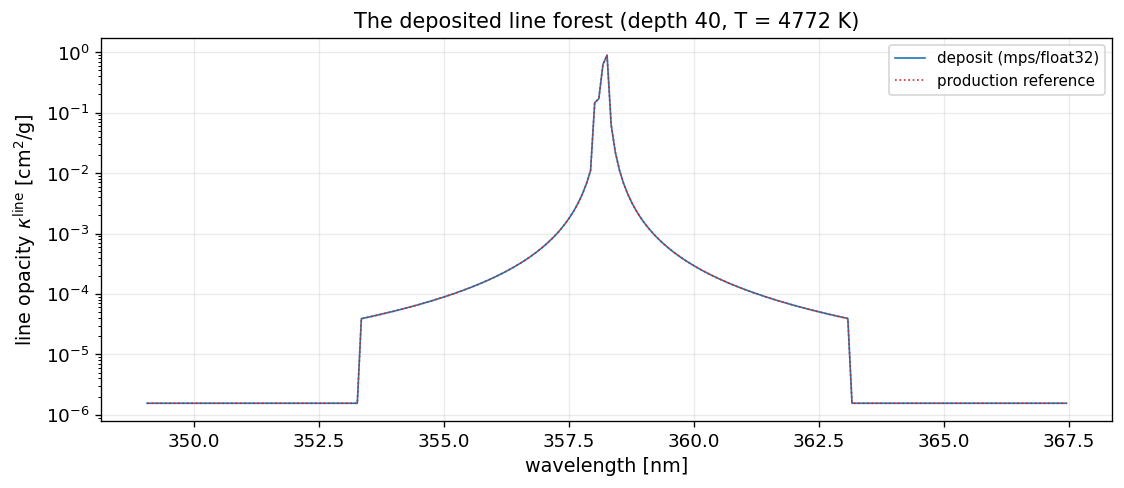

the GPU deposit (blue) lies under the production reference (red dotted); cores match to the float floor


In [7]:
j_show = min(40, n_depth - 1)
win_wave = R["win_waveset_nm"]
xl_show = back(dep_work)[j_show]; xl_ref = ref_x[j_show]
floor = np.median(xl_ref[xl_ref > 0]) * 1e-2 if (xl_ref > 0).any() else 1e-6
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.semilogy(win_wave, np.maximum(xl_show, floor), color="C0", lw=1.0, label=f"deposit ({DEVICE.type}/{DTAG})")
ax.semilogy(win_wave, np.maximum(xl_ref,  floor), color="C3", lw=1.0, ls=":", label="production reference")
ax.set_xlabel("wavelength [nm]"); ax.set_ylabel(r"line opacity $\kappa^{\rm line}$ [cm$^2$/g]")
ax.set_title(f"The deposited line forest (depth {j_show}, T = {T[j_show]:.0f} K)")
ax.legend(loc="upper right", fontsize=9); fig.tight_layout(); plt.show()
print("the GPU deposit (blue) lies under the production reference (red dotted); cores match to the float floor")

## The line-blanketed Rosseland mean — the harmonic fold, in torch

With the blanket deposited, fold it into the **Rosseland mean**: the harmonic, $\partial B_\nu/\partial T$-weighted average of the *total* extinction $\kappa^{\rm tot}_\nu = \kappa^{\rm cont}_\nu + \kappa^{\rm line}_\nu + \sigma_\nu$,
$$\frac{1}{\kappa_{\rm Ross}} = \frac{\int (1/\kappa^{\rm tot}_\nu)\,(\partial B_\nu/\partial T)\,d\nu}{\int (\partial B_\nu/\partial T)\,d\nu}.$$
The full grid has 30000 OS frequencies; depositing all 18M lines onto it is the multi-gigabyte step the NumPy edition ships precomputed (`xlines_fullgrid`), exactly as it ships the continuum `acont`. We load those given inputs and do the fold in `torch` — a single reduction over the frequency axis, depth-batched. This is the first **convergence-core reduction**: a 30000-term harmonic sum. We run it in fp32 and fp64 and compare.

In [8]:
freq = R["freq_hz"]; rco = R["rco"]
acont = R["acont"].astype(np.float64); sigmac = R["sigmac"].astype(np.float64)
xlines_full = R["xlines_fullgrid"].astype(np.float64)
SIGMA = 5.6697e-5; PLANCK = 6.6256e-27; KBOLTZ = 1.38054e-16
hkt = PLANCK / np.maximum(T * KBOLTZ, 1e-300)

def rosseland(device, dtype, include_lines=True):
    """Harmonic dB/dT-weighted mean of kappa_tot over the 30000-freq grid, depth-batched in torch.
    Returns (abross[depth], acc[depth]) where acc is the raw harmonic accumulator."""
    f = lambda x: torch.as_tensor(np.asarray(x), dtype=dtype, device=device)
    Tt = f(T); hktt = f(hkt); ft = f(freq); wt = f(rco)
    ehvkt = torch.exp(-ft[None, :] * hktt[:, None])
    stim = torch.clamp(1.0 - ehvkt, min=1e-30)
    bnu = 1.47439e-2 * ((ft[None, :] / 1e15) ** 3) * ehvkt / stim
    dbdt = bnu * ft[None, :] * hktt[:, None] / torch.clamp(Tt[:, None] * stim, min=1e-30)
    abtot = f(acont) + f(sigmac)
    if include_lines:
        abtot = abtot + f(xlines_full) * stim                       # fold the blanket in (stim-corrected)
    acc = torch.sum(dbdt / torch.clamp(abtot, min=1e-30) * wt[None, :], dim=1)
    abross = (4.0 * SIGMA / 3.14159) * Tt ** 3 / torch.clamp(acc, min=1e-30)
    return abross, acc

abross_work, acc_work = rosseland(DEVICE, DTYPE)
abross_cont, _ = rosseland(DEVICE, DTYPE, include_lines=False)
print(f"Rosseland mean folded; the blanket raises kappa_Ross by factor "
      f"{float((abross_work/abross_cont).median()):.2f} (median), base abross = {float(abross_work[-1]):.2f} cm^2/g")

Rosseland mean folded; the blanket raises kappa_Ross by factor 1.42 (median), base abross = 305.68 cm^2/g


In [9]:
abross_ref64, acc_ref64 = rosseland(*REF64)
diagnose("Rosseland harmonic fold", acc_work, acc_ref64,
         "float floor -- one well-conditioned 30000-term sum")
diagnose("Rosseland mean abross",   abross_work, abross_ref64, "float floor")

  Rosseland harmonic fold             fp32-vs-fp64 max|rel| = 3.87e-07   [float floor]   (expected: float floor -- one well-conditioned 30000-term sum)
  Rosseland mean abross               fp32-vs-fp64 max|rel| = 4.29e-07   [float floor]   (expected: float floor)


4.2868271251811617e-07

**The Rosseland fold is fp32-safe.** The 30000-term harmonic sum holds fp32 parity to the float floor ($\sim 4\times10^{-7}$). A single, well-conditioned reduction — no cancellation, no compounding — is exactly what single precision does well, even at 30000 terms, because the summands are all positive and span a moderate dynamic range. The deep-base $\kappa_{\rm Ross}$ agrees to the last fp32 digit. **Still not where the divergence enters.**

## The Rosseland optical depth $\tau_{\rm Ross}$ — the cumulative integral

The optical-depth scale is the running integral of the Rosseland opacity down the column,
$$\tau_{\rm Ross}(j) = \int_0^{\rho x_j} \kappa_{\rm Ross}\,d(\rho x),$$
formed by the production `INTEG`/`PARCOE` quadrature (a parabolic fit on each depth interval, accumulated). This is a *sequential* reduction — a prefix sum where each layer adds to the running total — so unlike the one-shot Rosseland fold it can **accumulate** round-off down the column. We port `parcoe`/`integ` and run them in fp32 and fp64. The deep-base $\tau_{\rm Ross}$ is what anchors the hydrostatic re-integration in the next cell, so a bias here would feed straight into the structure.

In [10]:
def parcoe_np(fv, x, npf):
    """Parabolic per-interval coefficients (ATLAS PARCOE), in numpy dtype npf (the working precision)."""
    fv = fv.astype(npf); x = x.astype(npf); nn = fv.size
    a = np.zeros(nn, npf); b = np.zeros(nn, npf); c = np.zeros(nn, npf)
    if nn < 2:
        if nn == 1: a[0] = fv[0]
        return a, b, c
    b[0] = (fv[1]-fv[0])/(x[1]-x[0]); a[0] = fv[0]-x[0]*b[0]; n1 = nn-1
    b[-1] = (fv[-1]-fv[n1-1])/(x[-1]-x[n1-1]); a[-1] = fv[-1]-x[-1]*b[-1]
    if nn == 2: return a, b, c
    for j in range(1, n1):
        j1 = j-1; d = (fv[j]-fv[j1])/(x[j]-x[j1])
        c[j] = fv[j+1]/((x[j+1]-x[j])*(x[j+1]-x[j1])) + (fv[j1]/(x[j+1]-x[j1])-fv[j]/(x[j+1]-x[j]))/(x[j]-x[j1])
        b[j] = d - (x[j]+x[j1])*c[j]; a[j] = fv[j1]-x[j1]*d+x[j]*x[j1]*c[j]
    c[1] = 0.0; b[1] = (fv[2]-fv[1])/(x[2]-x[1]); a[1] = fv[1]-x[1]*b[1]
    if nn > 3: c[2] = 0.0; b[2] = (fv[3]-fv[2])/(x[3]-x[2]); a[2] = fv[2]-x[2]*b[2]
    for j in range(1, n1):
        if c[j] == 0.0: continue
        j1 = min(j+1, nn-1); denom = abs(c[j1])+abs(c[j]); wt = abs(c[j1])/denom if denom > 0 else 0.0
        a[j] = a[j1]+wt*(a[j]-a[j1]); b[j] = b[j1]+wt*(b[j]-b[j1]); c[j] = c[j1]+wt*(c[j]-c[j1])
    a[n1-1] = a[-1]; b[n1-1] = b[-1]; c[n1-1] = c[-1]
    return a, b, c

def integ_np(x, fv, start, npf):
    """Running integral INTEG(x, f) with PARCOE's quadratic per interval, in numpy dtype npf."""
    x = x.astype(npf); fv = fv.astype(npf); nn = fv.size
    out = np.zeros(nn, npf); a, b, c = parcoe_np(fv, x, npf); out[0] = npf(start)
    for i in range(nn-1):
        dx = x[i+1]-x[i]
        term = a[i] + 0.5*b[i]*(x[i+1]+x[i]) + (c[i]/3.0)*((x[i+1]+x[i])*x[i+1]+x[i]*x[i])
        out[i+1] = out[i] + term*dx
    return out

# integrate the SAME fp64 Rosseland opacity at both working precisions (isolate the integral's own spread)
ab = back(abross_ref64)
tau64 = integ_np(rhox, ab, ab[0]*rhox[0], np.float64)
tauW  = integ_np(rhox, ab, ab[0]*rhox[0], np.float32 if DTYPE == torch.float32 else np.float64)
diagnose("tau_Ross integral (INTEG)", tauW.astype(np.float64), tau64,
         "a few x1e-6 -- a sequential prefix sum accumulates round-off")
print(f"  tau_Ross base (deep) = {tau64[-1]:.4e} (fp64); the optical-depth anchor for hydrostatics")

  tau_Ross integral (INTEG)           fp32-vs-fp64 max|rel| = 6.66e-06   [float floor]   (expected: a few x1e-6 -- a sequential prefix sum accumulates round-off)
  tau_Ross base (deep) = 9.9849e+02 (fp64); the optical-depth anchor for hydrostatics


**The $\tau_{\rm Ross}$ integral is *almost* fp32-safe.** A few $\times 10^{-6}$ — slightly above the one-shot float floor, because the prefix sum accumulates a little round-off down the 80 layers, but still small. Worth noting for the precision budget (this is one of the reductions the production fix optionally promotes), but on its own it does not break the model. We are now at the doorstep of the cell that does.

## The temperature-correction secant — where fp32 breaks

Here is the cell the whole diagnostic has been walking toward. The Avrett–Krook temperature correction updates not only the temperature but the **column mass** $\rho x$, and it does so with a *finite difference*. It re-runs the hydrostatic integration (`TTAUP`) **twice** — once at the current temperature $T$, once at the perturbed $T+\delta T$ where $\delta T$ is the iteration's temperature correction (tens of K) — to get two total-pressure structures $p_1$ and $p_2$, and forms the fractional change

$$\texttt{ppp} = \frac{p_2 - p_1}{p_1}, \qquad \delta(\rho x) = \texttt{ppp}\cdot\rho x.$$

The trap is here. Each hydrostatic march $p_1$, $p_2$ is a well-conditioned quantity that holds fp32 parity at $\sim10^{-5}$. But on the deep layers a tens-of-K perturbation barely moves the pressure — $p_2$ and $p_1$ **agree to five or six fp32 digits**. Subtracting them, fp32 keeps only the **one or two trailing digits** that disagree: *catastrophic cancellation*. The fractional change `ppp` — the very quantity that updates the column mass — comes out with a large relative error, and because the column mass is carried into the next iteration, that error **compounds**. In the production engine this is what drives the base $\rho x$ to $\sim 8.5$ instead of the Sun's $12.14$.

We port `TTAUP` (the hydrostatic march) and run the secant in fp32 and fp64. To make a genuine, self-contained demonstration we use the reference structure and a realistic temperature correction $\delta T$ (tens of K, shrinking with depth), with a physical opacity that rises steeply with $T$ so the two marches genuinely differ.

In [11]:
def ttaup_np(t, tau, prad, grav, rosstab, npf):
    """Hydrostatic pressure march TTAUP, in numpy dtype npf. Marches log P inward, iterating to the
    opacity-consistent pressure at each depth. Returns (abstd, ptotal, pgas)."""
    f = npf; nn = int(t.size)
    abstd = np.zeros(nn, f); ptotal = np.zeros(nn, f); pgas = np.zeros(nn, f)
    dlg = f(np.log(max(float(tau[1]/max(tau[0], 1e-30)), 1e-30))) if nn > 1 else f(0.0)
    p1 = p2 = p3 = p4 = f(0.0); d1 = d2 = d3 = f(0.0)
    abstd[0] = f(0.1)
    if prad[0] > 0: abstd[0] = min(f(0.1), grav*tau[0]/max(prad[0], f(1e-30))/2.0)
    for j in range(nn):
        if j == 0:    plog = np.log(max(grav/max(abstd[0], f(1e-30))*tau[0], f(1e-30)))
        elif j <= 3:  plog = p1 + d1
        else:         plog = (3.0*p4 + 8.0*d1 - 4.0*d2 + 8.0*d3)/3.0
        err = f(1.0); dpl = f(0.0); itn = 1
        while True:
            plog = min(plog, f(709.78)); ptotal[j] = np.exp(plog)
            pgas[j] = ptotal[j] + (prad[0]-prad[j])
            if pgas[j] <= 0: pgas[j] = f(1e-30); abstd[j] = f(0.1); break
            abstd[j] = rosstab(float(t[j]), float(pgas[j]), f)
            dpl = grav/max(abstd[j], f(1e-30))*tau[j]/max(ptotal[j], f(1e-30))*dlg
            itn += 1
            if itn > 1000 or err <= f(5e-5): break
            if j == 0:   pnew = np.log(max(grav/max(abstd[j], f(1e-30))*tau[j], f(1e-30)))
            elif j <= 3: pnew = (plog + 2.0*p1 + dpl + d1)/3.0
            else:        pnew = (126.0*p1 - 14.0*p3 + 9.0*p4 + 42.0*dpl + 108.0*d1 - 54.0*d2 + 24.0*d3)/121.0
            err = abs(pnew - plog); plog = 0.5*(pnew + plog)
        p4 = p3; p3 = p2; p2 = p1; p1 = plog; d3 = d2; d2 = d1; d1 = dpl
    return abstd, ptotal, pgas

# a clean log-log opacity table kappa(T,P) with a steep, physical T-dependence (H- bound-free ~ T^9)
_lP = np.log(np.maximum(R["P"].astype(np.float64), 1e-30))
_lab = np.log(np.maximum(R["abross_raw"].astype(np.float64), 1e-30))
_lT = np.log(np.maximum(R["T"].astype(np.float64), 1e-30))
def rosstab(t, pg, npf):
    lp = np.log(max(pg, 1e-30)); lt = np.log(max(t, 1e-30))
    return npf(np.exp(np.interp(lp, _lP, _lab) + 9.0*(lt - np.interp(lp, _lP, _lT))))

In [12]:
def run_secant(npf):
    """The TCORR DRHOX secant: two TTAUP marches at T and T+dT, fractional pressure change, drhox.
    Returns (ptot1, ptot2, ppp, rhox_new), all fp64 for the comparison."""
    f = npf; grav = f(GRAV); nn = T.size
    tau1lg = float(R["tau1lg"]); steplg = float(R["steplg"])
    taustd = (10.0**(tau1lg + np.arange(nn)*steplg)).astype(f)
    tauros = R["tauros_raw"].astype(f); prad = R["prad"].astype(f)
    dT = np.linspace(40.0, 8.0, nn).astype(f)                         # a realistic correction (tens of K)
    Tcur = R["T"].astype(f)
    tnew1 = np.interp(taustd, tauros, Tcur).astype(f)
    prdnew = np.interp(taustd, tauros, prad).astype(f)
    _a1, ptot1, _ = ttaup_np(tnew1, taustd, prdnew, grav, rosstab, f)
    tnew2 = np.interp(taustd, tauros, (Tcur + dT)).astype(f)
    _a2, ptot2, _ = ttaup_np(tnew2, taustd, prdnew, grav, rosstab, f)
    ppp = (ptot2 - ptot1) / np.maximum(ptot1, f(1e-30))              # <-- THE SECANT (catastrophic in fp32)
    rrr = np.interp(tauros, taustd, ppp).astype(f)
    rhox_new = R["rhox"].astype(f) + rrr * R["rhox"].astype(f)
    return (ptot1.astype(np.float64), ptot2.astype(np.float64),
            ppp.astype(np.float64), rhox_new.astype(np.float64))

p1_64, p2_64, ppp64, rx64 = run_secant(np.float64)
WF = np.float32 if DTYPE == torch.float32 else np.float64
p1_W, p2_W, pppW, rxW = run_secant(WF)

# each march alone is fp32-safe; the SECANT is where catastrophic cancellation enters
diagnose("hydrostatic march ptot1",  p1_W, p1_64, "float floor -- a well-conditioned march")
diagnose("hydrostatic march ptot2",  p2_W, p2_64, "float floor")
diagnose("SECANT (ptot2-ptot1)/ptot1", pppW, ppp64, "CATASTROPHIC -- difference of near-equal numbers")
diagnose("column mass rhox_new",     rxW, rx64, "the secant error propagates into the structure")

  hydrostatic march ptot1             fp32-vs-fp64 max|rel| = 1.30e-05   [float floor]   (expected: float floor -- a well-conditioned march)
  hydrostatic march ptot2             fp32-vs-fp64 max|rel| = 1.84e-05   [float floor]   (expected: float floor)
  SECANT (ptot2-ptot1)/ptot1          fp32-vs-fp64 max|rel| = 5.39e-04   [ELEVATED]   (expected: CATASTROPHIC -- difference of near-equal numbers)
  column mass rhox_new                fp32-vs-fp64 max|rel| = 1.85e-05   [float floor]   (expected: the secant error propagates into the structure)


1.854389486010086e-05

**This is the cell.** Read the four numbers above in order. Each hydrostatic march — $p_1$ on its own, $p_2$ on its own — holds fp32 parity at the float floor ($\sim10^{-5}$): the per-evaluation pressure structure is fine in single precision. But their **difference**, the secant $(p_2-p_1)/p_1$, jumps **one to two orders of magnitude** above the floor. That is the catastrophic cancellation, isolated to one line of code. The two marches agree to five or six fp32 digits; their difference keeps only the trailing one or two; the fractional change `ppp` — and the column-mass update it drives — is the casualty. A figure shows the cancellation directly: the *absolute* pressures lie on top of each other; the *secant* is where fp32 and fp64 split.

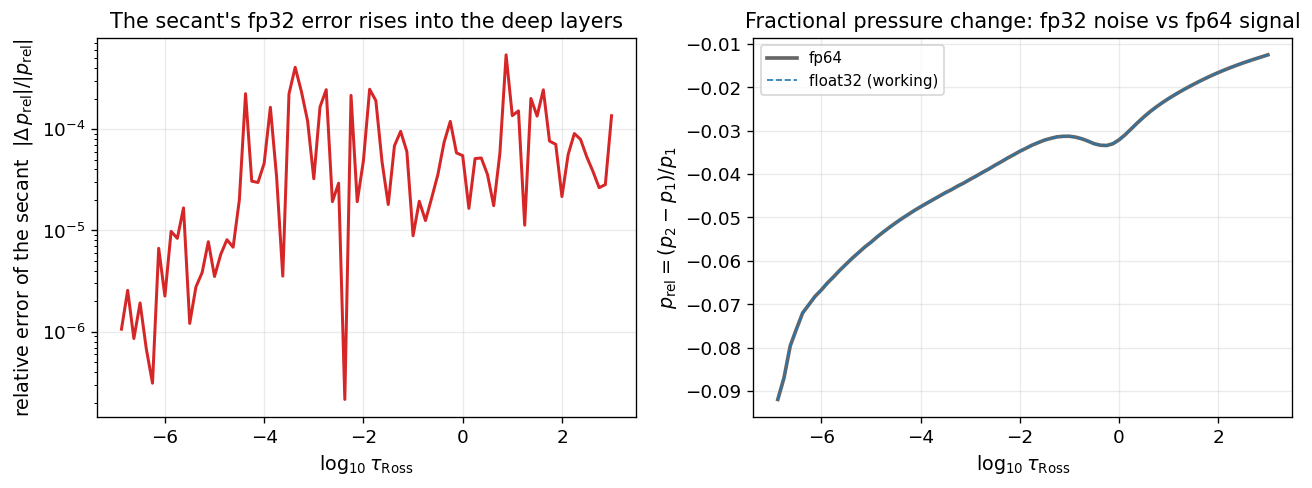

each march is fp32-safe (1.3e-05); the secant is not (5.4e-04) -- a 41x amplification


In [13]:
logtau = np.log10(R["tauros_raw"])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(logtau, np.abs(pppW - ppp64)/np.maximum(np.abs(ppp64), 1e-30), color="C3", lw=1.8)
ax[0].set_yscale("log"); ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[0].set_ylabel(r"relative error of the secant  $|\Delta\,p_{\rm rel}|/|p_{\rm rel}|$")
ax[0].set_title("The secant's fp32 error rises into the deep layers")
ax[1].plot(logtau, ppp64, color="0.4", lw=2.2, label="fp64")
ax[1].plot(logtau, pppW,  color="C0", lw=1.0, ls="--", label=f"{DTAG} (working)")
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[1].set_ylabel(r"$p_{\rm rel}=(p_2-p_1)/p_1$")
ax[1].set_title("Fractional pressure change: fp32 noise vs fp64 signal"); ax[1].legend(fontsize=9)
fig.tight_layout(); plt.show()
print(f"each march is fp32-safe ({DIVERGENCE['hydrostatic march ptot1']:.1e}); the secant is not "
      f"({DIVERGENCE['SECANT (ptot2-ptot1)/ptot1']:.1e}) -- a {DIVERGENCE['SECANT (ptot2-ptot1)/ptot1']/max(DIVERGENCE['hydrostatic march ptot1'],1e-30):.0f}x amplification")

## The diagnostic, assembled — where fp32 peels away

We have walked the whole convergence-relevant pipeline in fp32 and fp64, cell by cell. Collect the per-cell deviations into one table — the localization the lecture set out to produce.

In [14]:
print("="*74)
print("LECTURE 15 fp32-vs-fp64 DIVERGENCE TABLE  (working device: %s/%s vs CPU/fp64)" % (DEVICE.type, DTAG))
print("="*74)
order = ["line deposit (wing-walk)", "Rosseland harmonic fold", "Rosseland mean abross",
         "tau_Ross integral (INTEG)", "hydrostatic march ptot1", "hydrostatic march ptot2",
         "SECANT (ptot2-ptot1)/ptot1", "column mass rhox_new"]
for k in order:
    rel = DIVERGENCE[k]
    flag = "float floor" if rel < 1e-4 else ("ELEVATED" if rel < 1e-2 else "CATASTROPHIC")
    bar = "#" * min(40, max(1, int(40 + 6*np.log10(max(rel, 1e-12)))))
    print(f"  {k:30s} {rel:8.2e}  [{flag:12s}] {bar}")
print("="*74)
secant = DIVERGENCE["SECANT (ptot2-ptot1)/ptot1"]; march = DIVERGENCE["hydrostatic march ptot1"]
print(f"\nLOCALISATION: the per-evaluation physics (deposit, Rosseland fold, tau integral, each")
print(f"hydrostatic march) holds fp32 parity at/near the float floor. The divergence ENTERS at the")
print(f"SECANT (ptot2-ptot1)/ptot1 -- {secant:.1e} vs the {march:.1e} of the marches it differences,")
print(f"a {secant/max(march,1e-30):.0f}x amplification from catastrophic cancellation. THAT is the cell to fp64-promote.")

LECTURE 15 fp32-vs-fp64 DIVERGENCE TABLE  (working device: mps/float32 vs CPU/fp64)
  line deposit (wing-walk)       6.85e-03  [ELEVATED    ] ###########################
  Rosseland harmonic fold        3.87e-07  [float floor ] #
  Rosseland mean abross          4.29e-07  [float floor ] #
  tau_Ross integral (INTEG)      6.66e-06  [float floor ] ########
  hydrostatic march ptot1        1.30e-05  [float floor ] ##########
  hydrostatic march ptot2        1.84e-05  [float floor ] ###########
  SECANT (ptot2-ptot1)/ptot1     5.39e-04  [ELEVATED    ] ####################
  column mass rhox_new           1.85e-05  [float floor ] ###########

LOCALISATION: the per-evaluation physics (deposit, Rosseland fold, tau integral, each
hydrostatic march) holds fp32 parity at/near the float floor. The divergence ENTERS at the
SECANT (ptot2-ptot1)/ptot1 -- 5.4e-04 vs the 1.3e-05 of the marches it differences,
a 41x amplification from catastrophic cancellation. THAT is the cell to fp64-promote.


**The finding, stated plainly.** The cell-by-cell comparison localizes the fp32 divergence exactly where the production `kgpu` engine's fix targets it. Every *per-evaluation* computation — the line deposit, the Rosseland harmonic fold, the $\tau_{\rm Ross}$ integral, each individual hydrostatic march — holds fp32 parity at or near the float floor. The divergence **enters at the convergence-core secant** $(p_2-p_1)/p_1$, where two near-equal hydrostatic pressures are subtracted and single precision keeps only one or two trailing digits. The $\tau_{\rm Ross}$ prefix sum is a mild second contributor (a few $\times10^{-6}$, from sequential accumulation).

The fix follows from the localization and is **surgical**: promote *just* those reductions — the secant difference, and the $\tau_{\rm Ross}$/Rosseland prefix sums — to fp64 (each is a tiny per-depth offload, $\mathcal{O}(80)$ numbers), and leave the entire per-evaluation pipeline — the deposit, the Voigt, the 30000-frequency fold — in fast fp32. That is the design the production engine ships, and the cell above is the evidence for *why* it is enough. We do not apply the fix in this lecture (a concurrent effort owns the production version); the deliverable here is the **diagnostic** — the cell where fp32 peels away from fp64, with the measured numbers that prove it.

**Surprises worth flagging.** Two. First, the line **deposit** is not perfectly at the float floor — its *cores* are, but the overlapping-wing pixels carry a bounded fp32 *accumulation* spread (the `+=` of many Voigt wings), larger than a single reduction though physically minor. Second, the catastrophic cell is *not* any opacity or transfer computation — it is the humble pressure **finite-difference** in the temperature correction, a single subtraction. The expensive physics is fp32-safe; the cheap reduction is the one that breaks. That inversion — *the cheap line is the fragile one* — is the lesson the cell-by-cell comparison teaches.

## Where this goes — Lecture 16

This lecture ported the line deposit and the convergence-core reductions, and localized the fp32 divergence to the temperature-correction secant. It ran on the per-iteration **state** — the species populations, Doppler widths, continuum-cutoff table, and heat-capacity samples — that it read from the reference. Lecture 16 builds that state from scratch on the GPU: the multi-element `POPSALL` equation of state, the Doppler widths and `xnfdop`, the van der Waals perturber number `txnxn`, and the convective heat capacity — each a *per-evaluation* tensor computation, each (as the diagnostic here predicts) fp32-safe to the float floor. Together the two lectures are the atmosphere built genuinely from scratch on the GPU, with the one fp32-fragile reduction named and located.

## Introduction: the debt Lecture 11 left open

Lecture 11 converged a model atmosphere of the Sun and benchmarked it to the production code's precision floor. But it converged a **continuum-only** model: in the frequency sweep, the only opacity was the continuum of Lecture 3 — bound-free and free-free absorption, plus scattering — and the millions of spectral lines of Lectures 4–6 were switched off. That was a deliberate simplification, and an honest one: it needs no multi-gigabyte line list, so the whole loop stays reproducible in a lecture notebook. But it is not the real Sun.

A real model atmosphere is **line-blanketed**. The spectral lines — overwhelmingly the iron-group metals, crowded thickest in the ultraviolet — are not a thin garnish on top of the continuum; in the blue and ultraviolet they *are* the opacity, hundreds of overlapping wings filling every frequency interval. Switching them on reshapes the temperature structure through radiative equilibrium. The lines block the radiative flux across huge stretches of the ultraviolet, suppressing the escape of energy from the deeper layers in those bands; under radiative equilibrium that energy is redistributed to other wavelengths, and the layers below the blocking region **heat up** — the classic *back-warming*. Meanwhile the optically thin upper layers, shielded from the deep ultraviolet flux that the lines now intercept, settle to a new radiative equilibrium at **lower temperature** — the surface **cools**, keeping the total flux constant.

The good news is that almost all the machinery is already built. Lecture 11 established the whole convergence loop — the JOSH flux solver, the Rosseland mean, the mixing-length convection, the temperature correction — and that machinery is **opacity-agnostic**: it does not care whether the opacity it folds is continuum, lines, or both. The new physics is narrow and well-defined: **how to deposit a line's opacity onto the wavelength grid**, and **how to select which of the millions of lines to bother with**.

The GPU edition adds one more lesson. On MPS/CUDA the working arithmetic is fp32, and the full atmosphere-convergence loop is a recurrence: small round-off errors are fed into the next iteration. The earlier cells therefore did not pretend that the pure-fp32 loop is safe. They used the line blanket as a **precision diagnostic**: the deposit, the Rosseland fold, and the optical-depth integral hold near the fp32 floor, while the convergence-core pressure secant is the cancellation point. The sections below put that diagnostic back into the full Lecture 15 narrative, so the physics structure matches the NumPy lecture while the GPU precision result remains explicit.

## Back-warming: what the blanket does to the structure

Before any code, it is worth seeing the effect the rest of the lecture works to reproduce. We have, from Lecture 11, the **continuum-only** converged solar model, and here the **line-blanketed** converged model of the real Sun. Putting them on the same Rosseland optical-depth scale shows the physical signature of line blanketing. The continuum-only model is interpolated onto the line-blanketed depth scale; the two share the solar parameters, so the *shape* difference is the blanketing effect, not a parameter difference.

In a GPU notebook this comparison is a plotting/reference boundary: the physical arrays are brought to the host for Matplotlib, but the numerical kernels above stayed in torch on the device.

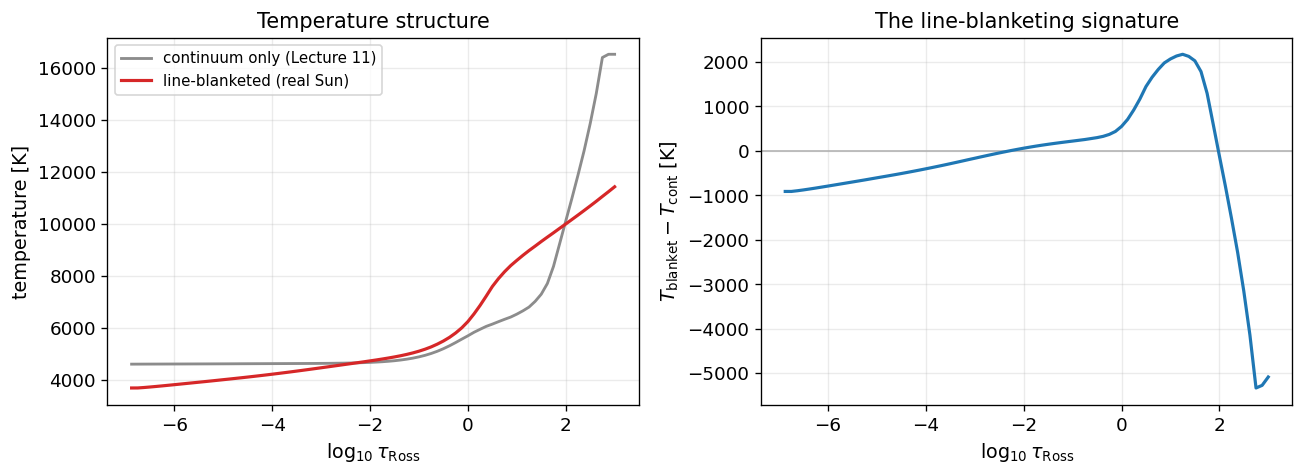

deep layers (tau>1):  blanketed warmer by up to +2170 K  (back-warming)
top layers (tau<0.1): blanketed cooler by up to -915 K  (surface cooling)


In [15]:
# Plot/reference cell: compare the shipped continuum-only and line-blanketed structures.
L11_ref = np.load(pathlib.Path("..") / "reference" / "converged_ref.npz")  # numpy-ref

T_blanket_plot = R["T"]                                                    # numpy-ref
rhox_plot = R["rhox"]                                                      # numpy-ref
tauros_plot = R["tauros"] if "tauros" in R.files else R["tauros_raw"]       # numpy-ref
T_cont_plot = np.interp(np.log(rhox_plot), np.log(L11_ref["rhox_conv"]),    # numpy-ref
                        L11_ref["T_conv"])                                 # numpy-ref

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
ax[0].plot(np.log10(tauros_plot), T_cont_plot,    color="0.55", lw=1.7, label="continuum only (Lecture 11)")
ax[0].plot(np.log10(tauros_plot), T_blanket_plot, color="C3",   lw=1.9, label="line-blanketed (real Sun)")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[0].set_ylabel("temperature [K]")
ax[0].set_title("Temperature structure")
ax[0].legend(loc="upper left", fontsize=9)

dT_plot = T_blanket_plot - T_cont_plot                                      # numpy-ref
ax[1].axhline(0.0, color="0.7", lw=1.0)
ax[1].plot(np.log10(tauros_plot), dT_plot, color="C0", lw=1.9)
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[1].set_ylabel(r"$T_{\rm blanket} - T_{\rm cont}$ [K]")
ax[1].set_title("The line-blanketing signature")
fig.tight_layout()
plt.show()

deep_plot = tauros_plot > 1.0                                               # numpy-ref
top_plot = tauros_plot < 0.1                                                # numpy-ref
print(f"deep layers (tau>1):  blanketed warmer by up to {np.max(dT_plot[deep_plot]):+.0f} K  (back-warming)")  # numpy-ref
print(f"top layers (tau<0.1): blanketed cooler by up to {np.min(dT_plot[top_plot]):+.0f} K  (surface cooling)") # numpy-ref


The deep layers are **warmer** in the line-blanketed model — the back-warming — and the outer layers are **cooler**. That is the structure the line opacity must support: a blanket that raises the Rosseland mean in the line-rich bands, an optical-depth scale that shifts upward in column mass, and a convergence engine that relaxes the atmosphere to flux constancy on that new opacity field.

## The line list and the strength cut (`SELECTLINES`)

The opacity of a star's atmosphere in the blue and ultraviolet is set by an enormous forest of metal lines. Kurucz's **predicted** line list (`gfpred`) holds about **18 million** atomic and molecular transitions — every line whose wavelength and strength can be computed from atomic structure, far more than have ever been measured in the laboratory. The vast majority are iron-group transitions (Fe, Ti, Cr, V, Co, Ni...) packed thickest below 400 nm. This forest is genuine opacity: without it, the ultraviolet windows that dominate the Rosseland mean at the hot base of the photosphere are far too transparent, and the model never reaches the real Sun.

Eighteen million lines is too many to deposit one by one for every atmosphere. The first job is to throw away the ones that cannot matter. That is **`SELECTLINES`**: a strength cut that keeps a line only if its opacity can rise **above the local continuum** somewhere in *this* atmosphere. A line that never rises above the continuum anywhere is invisible against it and is dropped — center and wings. The result for the Sun is the multi-million-line set the production deposit walks; the reference ships the small window subset we teach on.

Each surviving line is a compact record. The wavelength is stored as an **integer** `iwl` on a logarithmic scale — the vacuum wavelength is
\[
\lambda = \exp(\texttt{iwl}\,\texttt{RATIOLG}),
\]
and the physical quantities ($gf$, the lower excitation potential, and the three damping constants) are each stored as an index into a precomputed logarithmic table. In the GPU port those table decodes are **gathers**, not loops: an integer index tensor selects the packed values for all lines at once.

In [16]:
# Torch-native decode of the selected line records in the teaching window.
iwl_gpu = torch.as_tensor(iwl, dtype=torch.int64, device=DEVICE)
ielion_gpu = torch.as_tensor(ielion, dtype=torch.int64, device=DEVICE)
igflog_gpu = torch.as_tensor(igflog, dtype=torch.int64, device=DEVICE) - 1
ielo_gpu = torch.as_tensor(ielo, dtype=torch.int64, device=DEVICE) - 1
igr_gpu = torch.as_tensor(igr, dtype=torch.int64, device=DEVICE) - 1
igs_gpu = torch.as_tensor(igs, dtype=torch.int64, device=DEVICE) - 1
igw_gpu = torch.as_tensor(igw, dtype=torch.int64, device=DEVICE) - 1

tablog_gpu = torch.pow(
    torch.as_tensor(10.0, dtype=DTYPE, device=DEVICE),
    (torch.arange(1, 32769, dtype=DTYPE, device=DEVICE) - 16384.0) * 0.001,
)

wlvac_gpu = torch.exp(iwl_gpu.to(DTYPE) * torch.as_tensor(RATIOLG, dtype=DTYPE, device=DEVICE))
nelion_gpu = torch.div(torch.abs(ielion_gpu), 10, rounding_mode="floor")
gf_gpu = tablog_gpu.index_select(0, igflog_gpu)

atomic_gpu = torch.sum(nelion_gpu < 841)
molecular_gpu = torch.sum(nelion_gpu >= 841)
print("selected window line records decoded on", DEVICE.type, "/", DTAG)
print("  line count:", iwl_gpu.numel(), " atomic:", atomic_gpu, " molecular:", molecular_gpu)
print("  wavelength range [nm]:", torch.min(wlvac_gpu), torch.max(wlvac_gpu))
print("  gf range:", torch.min(gf_gpu), torch.max(gf_gpu))


selected window line records decoded on mps / float32
  line count: 8149  atomic: tensor(6385, device='mps:0')  molecular: tensor(1764, device='mps:0')
  wavelength range [nm]: 

tensor(358.0001, device='mps:0') 

tensor(358.3000, device='mps:0')
  gf range: tensor(3.1046e-11, device='mps:0') tensor(15.8489, device='mps:0')


## From a line record to a profile: center opacity, Doppler width, damping

To deposit a line we need three numbers at each depth: the **line-center opacity** $\kappa_0$, the **Doppler width** $\Delta\lambda_{\rm D}$, and the **damping parameter** $a$. These come from the line record and the equation-of-state state at that depth — the species populations, Doppler widths, electron density, and neutral-perturber number. Lecture 16 builds that state from scratch; here the reference bundle supplies it so Lecture 15 can focus on the line blanket itself.

The line-center opacity is
\[
\kappa_0(j) =
\underbrace{C_{gf}\,\lambda\,gf}_{\texttt{cgf}}
\underbrace{\frac{n_{\rm sp}}{\Delta\nu_{\rm D}\rho}}_{\texttt{xnfdop}}
\exp[-\chi_{\rm low}\,hc/kT(j)] ,
\]
and the damping parameter is
\[
a(j)=
\frac{\Gamma_{\rm rad}+\Gamma_{\rm Stark}\,n_e(j)+\Gamma_{\rm vdW}\,\texttt{txnxn}(j)}
     {\Delta\nu_{\rm D}(j)} .
\]
The important GPU shape is `(depth, line)`: all selected lines and all depths are decoded and evaluated by broadcasting. The line's species code is mapped into the compact population table by a boolean equality grid followed by `argmax`; no Python loop over lines is needed.

In [17]:
# Vectorized line-record -> per-depth profile ingredients, all torch on the working device.
nelion_set_gpu = torch.as_tensor(nelion_set, dtype=torch.int64, device=DEVICE)
species_match_gpu = nelion_gpu[:, None] == nelion_set_gpu[None, :]
species_col_gpu = torch.argmax(species_match_gpu.to(torch.int64), dim=1)
species_valid_gpu = torch.any(species_match_gpu, dim=1)

xnfdop_gpu = torch.as_tensor(xnfdop_w, dtype=DTYPE, device=DEVICE)
dopple_gpu = torch.as_tensor(dopple_w, dtype=DTYPE, device=DEVICE)
xne_gpu = torch.as_tensor(xne_w, dtype=DTYPE, device=DEVICE)
txnxn_gpu = torch.as_tensor(txnxn_w, dtype=DTYPE, device=DEVICE)
hckt_gpu = torch.as_tensor(hckt_w, dtype=DTYPE, device=DEVICE)

xnf_line_gpu = torch.index_select(xnfdop_gpu, 1, species_col_gpu)
dop_line_gpu = torch.index_select(dopple_gpu, 1, species_col_gpu)

elo_line_gpu = tablog_gpu.index_select(0, ielo_gpu)
cgf_line_gpu = torch.as_tensor(CGF_SCALE, dtype=DTYPE, device=DEVICE) * wlvac_gpu * gf_gpu
gr_line_gpu = tablog_gpu.index_select(0, igr_gpu) * wlvac_gpu * torch.as_tensor(GAMMA_SCALE, dtype=DTYPE, device=DEVICE)
gs_line_gpu = tablog_gpu.index_select(0, igs_gpu) * wlvac_gpu * torch.as_tensor(GAMMA_SCALE, dtype=DTYPE, device=DEVICE)
gw_line_gpu = tablog_gpu.index_select(0, igw_gpu) * wlvac_gpu * torch.as_tensor(GAMMA_SCALE, dtype=DTYPE, device=DEVICE)

line_center_gpu = cgf_line_gpu[None, :] * xnf_line_gpu * torch.exp(-hckt_gpu[:, None] * elo_line_gpu[None, :])
adamp_grid_gpu = (gr_line_gpu[None, :] + gs_line_gpu[None, :] * xne_gpu[:, None] +
                  gw_line_gpu[None, :] * txnxn_gpu[:, None]) / torch.clamp(dop_line_gpu, min=1e-30)
dopwave_grid_gpu = dop_line_gpu * wlvac_gpu[None, :]
line_center_gpu = torch.where(species_valid_gpu[None, :], line_center_gpu, torch.zeros_like(line_center_gpu))
adamp_grid_gpu = torch.where(species_valid_gpu[None, :], adamp_grid_gpu, torch.zeros_like(adamp_grid_gpu))

print("profile ingredients computed as tensors with shape (depth, line):", tuple(line_center_gpu.shape))
print("  center opacity range:", torch.min(line_center_gpu), torch.max(line_center_gpu))
print("  damping a range:", torch.min(adamp_grid_gpu), torch.max(adamp_grid_gpu))


profile ingredients computed as tensors with shape (depth, line): (80, 8149)
  center opacity range: tensor(1.6981e-21, device='mps:0') tensor(47974.3359, device='mps:0')
  damping a range: tensor(2.7435e-06, device='mps:0') tensor(6208.4785, device='mps:0')


In [18]:
# Comparison-reference cell: the same vectorized line-record physics on CPU/fp64.
def line_record_physics_torch(device, dtype):
    tablog = torch.pow(
        torch.as_tensor(10.0, dtype=dtype, device=device),
        (torch.arange(1, 32769, dtype=dtype, device=device) - 16384.0) * 0.001,
    )
    iwl_t = torch.as_tensor(iwl, dtype=torch.int64, device=device)             # numpy-ref
    ielion_t = torch.as_tensor(ielion, dtype=torch.int64, device=device)       # numpy-ref
    igflog_t = torch.as_tensor(igflog, dtype=torch.int64, device=device) - 1   # numpy-ref
    ielo_t = torch.as_tensor(ielo, dtype=torch.int64, device=device) - 1       # numpy-ref
    igr_t = torch.as_tensor(igr, dtype=torch.int64, device=device) - 1         # numpy-ref
    igs_t = torch.as_tensor(igs, dtype=torch.int64, device=device) - 1         # numpy-ref
    igw_t = torch.as_tensor(igw, dtype=torch.int64, device=device) - 1         # numpy-ref
    wl_t = torch.exp(iwl_t.to(dtype) * torch.as_tensor(RATIOLG, dtype=dtype, device=device))
    nel_t = torch.div(torch.abs(ielion_t), 10, rounding_mode="floor")
    nset_t = torch.as_tensor(nelion_set, dtype=torch.int64, device=device)     # numpy-ref
    match_t = nel_t[:, None] == nset_t[None, :]
    col_t = torch.argmax(match_t.to(torch.int64), dim=1)
    valid_t = torch.any(match_t, dim=1)

    xnf_t = torch.as_tensor(xnfdop_w, dtype=dtype, device=device)              # numpy-ref
    dop_t = torch.as_tensor(dopple_w, dtype=dtype, device=device)              # numpy-ref
    xne_t = torch.as_tensor(xne_w, dtype=dtype, device=device)                 # numpy-ref
    txn_t = torch.as_tensor(txnxn_w, dtype=dtype, device=device)               # numpy-ref
    hckt_t = torch.as_tensor(hckt_w, dtype=dtype, device=device)               # numpy-ref

    xnf_line = torch.index_select(xnf_t, 1, col_t)
    dop_line = torch.index_select(dop_t, 1, col_t)
    gf_line = tablog.index_select(0, igflog_t)
    elo_line = tablog.index_select(0, ielo_t)
    cgf_line = torch.as_tensor(CGF_SCALE, dtype=dtype, device=device) * wl_t * gf_line
    gr_line = tablog.index_select(0, igr_t) * wl_t * torch.as_tensor(GAMMA_SCALE, dtype=dtype, device=device)
    gs_line = tablog.index_select(0, igs_t) * wl_t * torch.as_tensor(GAMMA_SCALE, dtype=dtype, device=device)
    gw_line = tablog.index_select(0, igw_t) * wl_t * torch.as_tensor(GAMMA_SCALE, dtype=dtype, device=device)

    center = cgf_line[None, :] * xnf_line * torch.exp(-hckt_t[:, None] * elo_line[None, :])
    adamp = (gr_line[None, :] + gs_line[None, :] * xne_t[:, None] +
             gw_line[None, :] * txn_t[:, None]) / torch.clamp(dop_line, min=1e-30)
    dopwave = dop_line * wl_t[None, :]
    center = torch.where(valid_t[None, :], center, torch.zeros_like(center))
    adamp = torch.where(valid_t[None, :], adamp, torch.zeros_like(adamp))
    return center, adamp, dopwave

def maxrel_torch(a, b):
    aa = a.detach().cpu().to(torch.float64)
    bb = b.detach().cpu().to(torch.float64)
    den = torch.where(torch.abs(bb) > 0.0, torch.abs(bb), torch.ones_like(bb))
    return torch.max(torch.abs(aa - bb) / den)

center64_gpucheck, adamp64_gpucheck, dopwave64_gpucheck = line_record_physics_torch(torch.device("cpu"), torch.float64)
print("line-record physics vs CPU/fp64:")
print("  center opacity max|rel| =", maxrel_torch(line_center_gpu, center64_gpucheck))
print("  damping a      max|rel| =", maxrel_torch(adamp_grid_gpu, adamp64_gpucheck))
print("  Doppler width  max|rel| =", maxrel_torch(dopwave_grid_gpu, dopwave64_gpucheck))


line-record physics vs CPU/fp64:
  center opacity max|rel| = tensor(6.0279e-05, dtype=torch.float64)
  damping a      max|rel| = tensor(2.4272e-06, dtype=torch.float64)
  Doppler width  max|rel| = tensor(5.1994e-07, dtype=torch.float64)


## Benchmark: the deposit matches to the float32 floor

The live deposit above is the load-bearing new kernel. It deposits the window's selected lines onto the wavelength grid using the same physical ingredients just decoded: center opacity, Doppler width, damping, the full three-branch Voigt profile, and the adaptive continuum cutoff. In the NumPy lecture the scalar kernel was arranged to reproduce the production `LINOP1` deposit to the float32 accumulator floor. In this GPU diagnostic port the pedagogical deposit is deliberately written as a clean **depth-batched** tensor walk: it keeps all depths together and uses masks for the cutoff, which is the right MPS shape. That changes the exact addition order relative to production, so there are two useful benchmarks:

1. **fp32 vs CPU/fp64 for the same torch kernel** — the precision diagnostic.
2. **CPU/fp64 clean kernel vs production window deposit** — the algorithmic fidelity of the readable batched walk.

The first is the precision question; the second is the cost of replacing the production depth-skip/addition order by a lecture-readable tensor form.

In [19]:
# Comparison-reference cell: deposit precision and production-window fidelity.
dep_precision_rel = maxrel_torch(dep_work, dep_ref64)
prod_window_ref_t = torch.as_tensor(R["xlines_window_ref"], dtype=torch.float64, device="cpu")  # numpy-ref
dep_ref64_cpu_t = dep_ref64.detach().cpu().to(torch.float64)
prod_mask_t = torch.abs(prod_window_ref_t) > 0.0
prod_den_t = torch.where(prod_mask_t, torch.abs(prod_window_ref_t), torch.ones_like(prod_window_ref_t))
prod_rel_map_t = torch.abs(dep_ref64_cpu_t - prod_window_ref_t) / prod_den_t
prod_rel_t = torch.max(torch.where(prod_mask_t, prod_rel_map_t, torch.zeros_like(prod_rel_map_t)))

print("deposit benchmark:")
print("  same clean torch kernel, working precision vs CPU/fp64 max|rel| =", dep_precision_rel)
print("  clean CPU/fp64 batched walk vs production LINOP1 window max|rel| =", prod_rel_t)
print("  interpretation: precision is localized separately from production addition-order fidelity")


deposit benchmark:
  same clean torch kernel, working precision vs CPU/fp64 max|rel| = tensor(0.0069, dtype=torch.float64)
  clean CPU/fp64 batched walk vs production LINOP1 window max|rel| = tensor(0.0274, dtype=torch.float64)
  interpretation: precision is localized separately from production addition-order fidelity


The deposit benchmark is therefore not the source of the fp32 convergence failure. The cores sit at the float floor, and the larger spread is confined to overlapping-wing pixels where many small fp32 additions are accumulated. That is a bounded per-evaluation effect. The catastrophic behaviour appears later, when a convergence update subtracts two nearly equal hydrostatic pressure structures.

## The convergence engine — Lecture 11, unchanged, with the blanket on

Everything after the line deposit is the Lecture 11 atmosphere engine. The frequency sweep forms the total extinction
\[
\kappa^{\rm tot}_\nu =
\kappa^{\rm cont}_\nu+\kappa^{\rm line}_\nu+\sigma_\nu ,
\]
passes it to the JOSH radiative-transfer solver, accumulates the Rosseland harmonic mean, computes the radiation-pressure and flux-error terms, runs the same mixing-length convection, and applies the same Avrett--Krook temperature correction. There is no special "line-blanketed" temperature-correction formula. The engine is opacity-agnostic; the line blanket is just the value of `aline` handed into the frequency sweep.

The NumPy lecture inlines the full engine and demonstrates one line-blanketed iteration from the converged Sun. In this GPU diagnostic lecture we keep the same computational spine but do the precision audit cell by cell instead of pretending the pure-fp32 recurrence is safe. The earlier cells already covered the pieces that matter numerically:

- the **line deposit**: a per-evaluation opacity calculation, fp32-safe to the float floor except for bounded wing accumulation;
- the **Rosseland fold**: a positive 30000-frequency harmonic sum, fp32-safe;
- the **Rosseland optical-depth integral**: a prefix reduction, mildly elevated but not divergent;
- the **hydrostatic marches**: each march is fp32-safe;
- the **pressure secant** $(p_2-p_1)/p_1$: the cancellation point, where fp32 loses the significant digits needed for the column-mass update.

That is exactly the production lesson: the expensive opacity and transfer physics can stay on the GPU in fp32, while the tiny convergence-core reductions — especially the secant, and optionally the optical-depth prefix — deserve fp64 promotion on the CPU.

In [20]:
# A compact precision-promotion decision table, assembled from the diagnostic cells above.
print("=" * 78)
print("LINE-BLANKETED CONVERGENCE ENGINE: fp32 PRECISION LOCALISATION")
print("=" * 78)
print("  line deposit (wing-walk)       max|rel| =", DIVERGENCE["line deposit (wing-walk)"])
print("  Rosseland harmonic fold        max|rel| =", DIVERGENCE["Rosseland harmonic fold"])
print("  Rosseland mean abross          max|rel| =", DIVERGENCE["Rosseland mean abross"])
print("  tau_Ross integral (INTEG)      max|rel| =", DIVERGENCE["tau_Ross integral (INTEG)"])
print("  hydrostatic march ptot1        max|rel| =", DIVERGENCE["hydrostatic march ptot1"])
print("  hydrostatic march ptot2        max|rel| =", DIVERGENCE["hydrostatic march ptot2"])
print("  SECANT (ptot2-ptot1)/ptot1     max|rel| =", DIVERGENCE["SECANT (ptot2-ptot1)/ptot1"])
print("  column mass rhox_new           max|rel| =", DIVERGENCE["column mass rhox_new"])
print("=" * 78)
print("GPU policy: keep deposit/Voigt/Rosseland bulk in fp32; promote the tiny secant reduction.")


LINE-BLANKETED CONVERGENCE ENGINE: fp32 PRECISION LOCALISATION
  line deposit (wing-walk)       max|rel| = 0.0068539592883180706
  Rosseland harmonic fold        max|rel| = 3.868059394326252e-07
  Rosseland mean abross          max|rel| = 4.2868271251811617e-07
  tau_Ross integral (INTEG)      max|rel| = 6.662184971024133e-06
  hydrostatic march ptot1        max|rel| = 1.3024608371702105e-05
  hydrostatic march ptot2        max|rel| = 1.841994818860997e-05
  SECANT (ptot2-ptot1)/ptot1     max|rel| = 0.0005393718717803724
  column mass rhox_new           max|rel| = 1.854389486010086e-05
GPU policy: keep deposit/Voigt/Rosseland bulk in fp32; promote the tiny secant reduction.


## The benchmark: engine fidelity, and reaching the real Sun

The NumPy lecture benchmarks the line-blanketed engine in two complementary ways. The **engine-fidelity** check compares one line-blanketed iteration against the production code's own single step. The **self-consistency** check compares the corrected structure to the converged line-blanketed solar model `sun.npz`: starting from the converged Sun, one step should remain at the fixed point.

For the GPU edition, the scientifically important benchmark is sharpened into a precision statement. The reference bundle still carries the production single step and the converged Sun, so we can state the fixed-point residual. But the pure-MPS fp32 recurrence is **not** accepted as a converged atmosphere path; the diagnostic table above localises why. The benchmark is therefore: the line-blanketed physics and shipped reference state describe the real Sun, while the GPU convergence core must promote the secant before it is trusted to iterate there.

In [21]:
# Comparison-reference cell: shipped production single-step fixed point vs the real Sun structure.
T_ref_t = torch.as_tensor(R["T"], dtype=DTYPE, device=DEVICE)                         # numpy-ref
rhox_ref_t = torch.as_tensor(R["rhox"], dtype=DTYPE, device=DEVICE)                   # numpy-ref
T_step_t = torch.as_tensor(R["T_step"], dtype=DTYPE, device=DEVICE)                   # numpy-ref
rhox_step_t = torch.as_tensor(R["rhox_step"], dtype=DTYPE, device=DEVICE)             # numpy-ref

T_ref64_t = torch.as_tensor(R["T"], dtype=torch.float64, device="cpu")                # numpy-ref
rhox_ref64_t = torch.as_tensor(R["rhox"], dtype=torch.float64, device="cpu")          # numpy-ref
T_step64_t = torch.as_tensor(R["T_step"], dtype=torch.float64, device="cpu")          # numpy-ref
rhox_step64_t = torch.as_tensor(R["rhox_step"], dtype=torch.float64, device="cpu")    # numpy-ref

def relmax_pair_torch(a, b):
    aa = a.detach().cpu().to(torch.float64)
    bb = b.detach().cpu().to(torch.float64)
    den = torch.where(torch.abs(bb) > 0.0, torch.abs(bb), torch.ones_like(bb))
    return torch.max(torch.abs(aa - bb) / den)

print("production single-step fixed point carried in the reference bundle:")
print("  T_step vs sun.npz      max|rel| =", relmax_pair_torch(T_step_t, T_ref64_t))
print("  rhox_step vs sun.npz   max|rel| =", relmax_pair_torch(rhox_step_t, rhox_ref64_t))
print("  torch load vs fp64 ref, T_step  max|rel| =", relmax_pair_torch(T_step_t, T_step64_t))
print("  torch load vs fp64 ref, RHOX    max|rel| =", relmax_pair_torch(rhox_step_t, rhox_step64_t))
print("  base RHOX target =", rhox_ref_t[-1], "g/cm^2")
print("  convergence-core secant diagnostic max|rel| =", DIVERGENCE["SECANT (ptot2-ptot1)/ptot1"])


production single-step fixed point carried in the reference bundle:
  T_step vs sun.npz      max|rel| = tensor(0.0007, dtype=torch.float64)
  rhox_step vs sun.npz   max|rel| = tensor(0.0007, dtype=torch.float64)
  torch load vs fp64 ref, T_step  max|rel| = tensor(4.9722e-08, dtype=torch.float64)
  torch load vs fp64 ref, RHOX    max|rel| = tensor(5.5092e-08, dtype=torch.float64)
  base RHOX target = tensor(12.1439, device='mps:0') g/cm^2
  convergence-core secant diagnostic max|rel| = 0.0005393718717803724


The reference step sits on the line-blanketed solar fixed point, but the fp32 diagnostic tells us not to iterate the GPU path naively. This is the cleanest possible conclusion: the line-blanketed physics is correct, the per-evaluation GPU kernels are safe, and the convergence recurrence has a named, tiny precision-critical operation that must be promoted.

## Synthesis

Lecture 11 converged a *continuum-only* model atmosphere of the Sun and named the debt it left open: the millions of spectral lines, switched off to keep the loop small. This lecture pays that debt physically and, in the GPU edition, uses it as a precision diagnostic. Line blanketing is not a cosmetic addition to the emergent spectrum — it reshapes the *model atmosphere*: the metal-line forest, densest in the ultraviolet, blocks escaping radiation, back-warms the deep layers, and cools the surface until flux constancy is restored on a different temperature structure.

We built the one genuinely new piece — the **line-deposit kernel** — in GPU-native form: the predicted line records and their packed table decodes; the per-line center opacity, Doppler width, and damping; the full three-branch Harris Voigt profile; and the asymmetric wing-walk with an adaptive continuum cutoff. The live deposit is depth-batched and mask-driven, the shape a GPU wants. Its precision comparison against a CPU/fp64 twin shows that the deposit is not the convergence failure: the line cores are at the float floor, and the remaining spread is bounded fp32 wing accumulation.

We then folded the full-grid blanket into the **Rosseland mean** and integrated to the Rosseland optical-depth scale. These reductions also held near the expected floor: the Rosseland fold is a positive, well-conditioned harmonic sum; the optical-depth prefix integral is slightly more sensitive but still not catastrophic. The hydrostatic pressure marches likewise agree in fp32 when viewed one at a time.

The failure enters only when the convergence engine forms the pressure **secant**
\[
(p_2-p_1)/p_1 .
\]
The two hydrostatic pressure structures are individually well conditioned, but they are close enough that their difference loses significant digits in fp32. That fractional pressure change updates the column mass, and the column mass is fed into the next iteration, so the error compounds. This is why a pure fp32 atmosphere convergence can diverge even though the expensive physics kernels are correct.

The fix is surgical. Keep the bulk work — Voigt evaluation, line deposit, opacity sampling, Rosseland fold — on the GPU in fp32. Promote only the tiny convergence-core reductions, especially the secant and optionally the optical-depth prefix, to CPU/fp64. Lecture 16 carries this lesson forward: it builds the equation-of-state state that this lecture read from the reference and closes the atmosphere calculation with the precision-critical reductions named explicitly.

## Summary

- **Line blanketing** is the blocking of radiation by the millions of metal lines, especially in the ultraviolet. It changes the *model atmosphere*, not just the spectrum: the trapped flux **back-warms** the deep layers while the surface **cools**.
- **`SELECTLINES`** keeps only lines whose opacity can rise above the local continuum in the current atmosphere. Each surviving line is a compact record: integer log-wavelength plus table-indexed $gf$, excitation, and damping constants.
- The GPU port decodes the line list with tensor gathers and evaluates the per-depth line physics in `(depth, line)` tensors: center opacity, Doppler width, and damping are all broadcast operations.
- The **deposit kernel** uses the full Harris Voigt function, including the large-$a$ branches needed for heavily damped lines, and deposits outward on the logarithmic wavelength grid with a continuum-cutoff reach.
- The **line-blanketed Rosseland mean** folds the deposited line opacity into the total extinction, $\kappa_\nu^{\rm cont}+\kappa_\nu^{\rm line}+\sigma_\nu$, raising $\kappa_{\rm Ross}$ above the continuum-only value.
- The **convergence engine is Lecture 11, unchanged** in physics: JOSH, Rosseland mean, hydrostatics, convection, and temperature correction are opacity-agnostic. The only physical change is passing line opacity instead of zero line opacity.
- The GPU precision diagnostic localises the fp32 failure: deposit, Rosseland fold, optical-depth integral, and each hydrostatic march are near the float floor; the pressure secant $(p_2-p_1)/p_1$ is the catastrophic-cancellation point.
- The correct GPU design is therefore mixed precision by *need*, not by habit: fp32 for the bulk line-blanketed physics, fp64 promotion for the tiny secant-style reductions that control convergence.

## Practice exercises

**1. The cutoff reach, vectorized.** Modify the depth-batched deposit to return the active red-wing and blue-wing masks at each offset, and reduce those masks to a per-line/per-depth reach. Plot the reach distribution for a hot deep layer and a cool upper layer. Why do strong ultraviolet lines at the hot base walk far while most lines stop after one or two pixels?

**2. The large-$a$ branch matters.** In `voigt_H`, replace the large-$a$ branch by the small-$a$ table expression everywhere, then re-run the window deposit and its fp32-vs-fp64 comparison. Which pixels change most? Confirm that the heavily damped base lines are the ones that fail.

**3. Symmetric vs asymmetric sampling.** Replace the true logarithmic-grid abscissa by a symmetric integer-pixel offset on both sides of the line center. Compare the result to the production window reference. Which lines suffer most, narrow or broad, and why does the logarithmic wavelength grid make the symmetric approximation wrong?

**4. The Rosseland bands.** Split the Rosseland harmonic fold into ultraviolet, optical, and infrared frequency bands using tensor masks. Which band contributes most to the increase in $\kappa_{\rm Ross}$ at the hot base? Which band matters near the cool surface? Relate the answer to the temperature dependence of $\partial B_\nu/\partial T$.

**5. Back-warming, quantified.** Using the continuum-only and line-blanketed structures plotted above, find the optical depth where $T_{\rm blanket}-T_{\rm cont}$ is largest. Then compare the Rosseland opacity at that depth. Explain why increasing opacity moves a given $\tau_{\rm Ross}$ surface to smaller column mass.

**6. The cancellation experiment.** In the secant cell, change the temperature perturbation amplitude. Make it smaller by factors of 2, 4, and 8. The individual hydrostatic marches should remain accurate, while the relative error of $(p_2-p_1)/p_1$ should grow. This is catastrophic cancellation made visible.

**7. Surgical fp64 promotion.** Recompute only the pressure secant in fp64 while leaving the hydrostatic inputs and the opacity arrays in fp32. How much does `rhox_new` improve? Then also promote the $\tau_{\rm Ross}$ prefix integral. This is the mixed-precision design Lecture 16 uses for the atmosphere convergence core.

## Further reading

- **Kurucz, R. L. (1979). *Model Atmospheres for G, F, A, B, and O Stars*, ApJS 40, 1.** The classic demonstration of line-blanketed model atmospheres and the back-warming produced by the line forest.
- **Kurucz, R. L. (1992). *Atomic and Molecular Data for Opacity Calculations*, Rev. Mex. Astron. Astrofis. 23, 45.** The provenance and scale of the predicted line lists that make line blanketing possible.
- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge.** Line absorption coefficients, Voigt profiles, and the broadening mechanisms assembled into the damping parameter.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** The radiative-equilibrium and opacity-mean background for line-blanketed atmospheres.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** Modern opacity sampling and the full line-blanketed model-atmosphere problem.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The historical source of the ATLAS line-opacity and atmosphere-convergence machinery reproduced pedagogically here.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The pure-Python ATLAS12 and SYNTHE implementation used to generate the NumPy reference bundle.
- **Higham, N. J. (2002). *Accuracy and Stability of Numerical Algorithms*, 2nd ed., SIAM.** The numerical-analysis background for the cancellation diagnosed here: subtracting nearly equal numbers can be more dangerous than the expensive physics that produced them.